# Video Game Data Analysis

## Business Context
This analysis explores video game data to understand player engagement, popularity, and factors influencing ratings.

## Objective
Analyze relationships between game characteristics (genres, developers, popularity metrics) and user ratings.

## Key Questions
- Which genres are most popular?
- Which genres have higher ratings?
- Which developers produce the highest-rated games?
- What factors drive game popularity?

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
df=pd.read_csv("games.csv",index_col=0)
df.shape

(1512, 13)

## Initial Exploration

In [3]:
df.info()
df.describe()
df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              1512 non-null   object 
 1   Release Date       1512 non-null   object 
 2   Team               1511 non-null   object 
 3   Rating             1499 non-null   float64
 4   Times Listed       1512 non-null   object 
 5   Number of Reviews  1512 non-null   object 
 6   Genres             1512 non-null   object 
 7   Summary            1511 non-null   object 
 8   Reviews            1512 non-null   object 
 9   Plays              1512 non-null   object 
 10  Playing            1512 non-null   object 
 11  Backlogs           1512 non-null   object 
 12  Wishlist           1512 non-null   object 
dtypes: float64(1), object(12)
memory usage: 165.4+ KB


,Title,Release Date,Team,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
count,1512,1512,1511,1512,1512,1512,1511,1512,1512,1512,1512,1512
unique,1099,987,764,606,606,255,1112,1117,258,396,544,573
top,Doom,"Nov 12, 2020",['Capcom'],1.1K,1.1K,"['Adventure', 'RPG']",Minecraft focuses on allowing the player to ex...,[],12K,1.1K,1.5K,1.3K
freq,7,8,35,46,46,154,4,12,50,24,52,41


## Column Name Cleaning

We standardize column names by removing spaces, trimming text, and converting them to uppercase for consistency.

In [4]:
df.columns=(df.columns.str.strip().str.upper().str.replace(" ","_"))

Insight:
Standardizing column names simplifies data manipulation and reduces the risk of errors during analysis.

## Remove Irrelevant Columns

We remove columns that do not add value to the analysis, such as text-heavy fields that are not used for modeling or aggregation.

In [5]:
df = df.drop(columns=["SUMMARY","REVIEWS"], errors="ignore")
df.head()

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST
0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']",17K,3.8K,4.6K,4.8K
1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",21K,3.2K,6.3K,3.6K
2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",30K,2.5K,5K,2.6K
3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",28K,679,4.9K,1.8K
4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",21K,2.4K,8.3K,2.3K


Insight: Removing unnecessary columns simplifies the dataset and improves analysis efficiency.

## Numeric Cleaning

Some columns contain values with "K" notation (e.g., 1.5K).  
We convert them into numeric format for proper analysis.

In [6]:
def convert_k(x):
    if "K" in str(x):
        return float(x.replace("K","")) * 1000
    return float(x)

cols = [
    "TIMES_LISTED",
    "NUMBER_OF_REVIEWS",
    "PLAYS",
    "PLAYING",
    "BACKLOGS",
    "WISHLIST"
]

for col in cols:
    df[col] = df[col].apply(convert_k)

Insight: Converting these values ensures consistency and allows accurate numerical analysis.

## Date Cleaning

We convert the release date column into datetime format to enable time-based analysis.

In [7]:
df["RELEASE_DATE"] = pd.to_datetime(df["RELEASE_DATE"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 0 to 1511
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TITLE              1512 non-null   object        
 1   RELEASE_DATE       1509 non-null   datetime64[ns]
 2   TEAM               1511 non-null   object        
 3   RATING             1499 non-null   float64       
 4   TIMES_LISTED       1512 non-null   float64       
 5   NUMBER_OF_REVIEWS  1512 non-null   float64       
 6   GENRES             1512 non-null   object        
 7   PLAYS              1512 non-null   float64       
 8   PLAYING            1512 non-null   float64       
 9   BACKLOGS           1512 non-null   float64       
 10  WISHLIST           1512 non-null   float64       
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 141.8+ KB


Insight: Some invalid dates were converted to null values, which will be handled in the missing values step.

## Missing Values Analysis

We evaluate the presence of missing values and their potential impact on the analysis.

In [8]:
print(df.isna().sum())
print()
print(df.shape)

TITLE                 0
RELEASE_DATE          3
TEAM                  1
RATING               13
TIMES_LISTED          0
NUMBER_OF_REVIEWS     0
GENRES                0
PLAYS                 0
PLAYING               0
BACKLOGS              0
WISHLIST              0
dtype: int64

(1512, 11)


In [9]:
df[df.isna().any(axis=1)]

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST
587,Final Fantasy XVI,2023-06-22,"['Square Enix', 'Square Enix Creative Business...",NaN,422.0,422.0,['RPG'],37.0,10.0,732.0,2400.0
644,Deltarune,NaT,['tobyfox'],4.3,313.0,313.0,"['Adventure', 'Indie', 'Music', 'Puzzle', 'RPG']",1300.0,83.0,468.0,617.0
649,Death Stranding 2,NaT,['Kojima Productions'],NaN,105.0,105.0,"['Adventure', 'Shooter']",3.0,0.0,209.0,644.0
713,Final Fantasy VII Rebirth,2023-12-31,['Square Enix'],NaN,192.0,192.0,[],20.0,3.0,354.0,1100.0
719,Lies of P,2023-08-01,"['NEOWIZ', 'Round8 Studio']",NaN,175.0,175.0,['RPG'],5.0,0.0,260.0,939.0
726,Judas,2025-03-31,['Ghost Story Games'],NaN,90.0,90.0,"['Adventure', 'Shooter']",1.0,0.0,92.0,437.0
746,Like a Dragon Gaiden: The Man Who Erased His Name,2023-12-31,"['Ryū Ga Gotoku Studios', 'Sega']",NaN,118.0,118.0,"['Adventure', 'Brawler', 'RPG']",2.0,1.0,145.0,588.0
972,The Legend of Zelda: Tears of the Kingdom,2023-05-12,"['Nintendo', 'Nintendo EPD Production Group No...",NaN,581.0,581.0,"['Adventure', 'RPG']",72.0,6.0,1600.0,5400.0
1130,Star Wars Jedi: Survivor,2023-04-28,"['Respawn Entertainment', 'Electronic Arts']",NaN,250.0,250.0,['Adventure'],13.0,2.0,367.0,1400.0
1160,We Love Katamari Reroll + Royal Reverie,2023-06-02,"['Bandai Namco Entertainment', 'MONKEYCRAFT Co...",NaN,51.0,51.0,"['Adventure', 'Puzzle']",3.0,0.0,74.0,291.0


In [10]:
df["RATING"] = df["RATING"].fillna(df["RATING"].median())
df = df.dropna(subset=["RELEASE_DATE","TEAM"])

Insight: Missing ratings were imputed using the median to preserve the dataset, while critical fields such as release date and team were retained to ensure data integrity.

## Duplicate Analysis

We check for duplicate records that could bias the analysis.

In [11]:
df[df.duplicated(keep=False)]
df.duplicated().sum()

np.int64(392)

Insight: A large number of duplicate records were identified, indicating repeated entries of the same games.

In [12]:
df[df.duplicated(subset=["TITLE","RELEASE_DATE"], keep=False)]

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3900.0,3900.0,"['Adventure', 'RPG']",17000.0,3800.0,4600.0,4800.0
1,Hades,2019-12-10,['Supergiant Games'],4.3,2900.0,2900.0,"['Adventure', 'Brawler', 'Indie', 'RPG']",21000.0,3200.0,6300.0,3600.0
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4300.0,4300.0,"['Adventure', 'RPG']",30000.0,2500.0,5000.0,2600.0
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3500.0,3500.0,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",28000.0,679.0,4900.0,1800.0
4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3000.0,3000.0,"['Adventure', 'Indie', 'Platform']",21000.0,2400.0,8300.0,2300.0
...,...,...,...,...,...,...,...,...,...,...,...
1269,Final Fantasy XIII-2,2011-12-15,['Square Enix'],3.3,482.0,482.0,"['Adventure', 'RPG']",2300.0,58.0,1400.0,449.0
1270,Agar.io,2015-04-28,"['Miniclip.com', 'Matheus Valadares']",2.2,81.0,81.0,"['Indie', 'Strategy']",4400.0,8.0,40.0,12.0
1271,Fatal Frame II: Crimson Butterfly,2003-11-27,"['Tecmo Co., Ltd.', 'Ubisoft Entertainment']",4.2,398.0,398.0,['Adventure'],1000.0,38.0,690.0,513.0
1466,FIFA 13,2012-09-25,"['Electronic Arts', 'EA Canada']",3.2,62.0,62.0,"['Simulator', 'Sport']",1600.0,2.0,34.0,12.0


In [13]:
df = df.drop_duplicates(subset=["TITLE","RELEASE_DATE"])
df.duplicated().sum()

np.int64(0)

Insight: Duplicates were removed to ensure each game is represented only once, improving the accuracy of the analysis.

In [14]:
print(df.describe())

                        RELEASE_DATE       RATING  TIMES_LISTED  \
count                           1113  1113.000000   1113.000000   
mean   2012-03-19 23:49:38.975741440     3.660018    607.805930   
min              1980-05-22 00:00:00     0.700000      0.000000   
25%              2006-10-17 00:00:00     3.400000    233.000000   
50%              2013-10-29 00:00:00     3.700000    445.000000   
75%              2019-05-14 00:00:00     4.000000    783.000000   
max              2025-03-31 00:00:00     4.600000   4300.000000   
std                              NaN     0.534520    559.802984   

       NUMBER_OF_REVIEWS         PLAYS      PLAYING     BACKLOGS     WISHLIST  
count        1113.000000   1113.000000  1113.000000  1113.000000  1113.000000  
mean          607.805930   4986.290207   186.670261  1168.759209   609.930818  
min             0.000000      0.000000     0.000000     1.000000     2.000000  
25%           233.000000   1500.000000    33.000000   385.000000   178.00000

Insight:
The dataset shows wide variability in engagement metrics such as plays and wishlist, suggesting a highly skewed distribution where a few games dominate user attention.

## Feature Engineering

In [15]:
df = df.assign(
    YEAR=df["RELEASE_DATE"].dt.year,
    MONTH=df["RELEASE_DATE"].dt.month
)
df["DECADE"]=(df["YEAR"]//10)*10

In [16]:
df["DECADE"].value_counts()

DECADE
2010    487
2000    270
2020    235
1990    106
1980     15
Name: count, dtype: int64

In [17]:
df = df.reset_index(drop=True)

## Exploratory Data Analysis

## Top Games by Popularity

In [18]:
df.sort_values("PLAYS", ascending=False).head(10)

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST,YEAR,MONTH,DECADE
5,Minecraft,2011-11-18,['Mojang Studios'],4.3,2300.0,2300.0,"['Adventure', 'Simulator']",33000.0,1800.0,1100.0,230.0,2011,11,2010
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4300.0,4300.0,"['Adventure', 'RPG']",30000.0,2500.0,5000.0,2600.0,2017,3,2010
23,Grand Theft Auto V,2013-09-17,"['Rockstar North', 'Rockstar Games']",3.8,2100.0,2100.0,"['Adventure', 'Shooter']",30000.0,829.0,3200.0,664.0,2013,9,2010
13,Portal 2,2011-04-18,"['Valve', 'Electronic Arts']",4.4,2900.0,2900.0,"['Adventure', 'Platform', 'Puzzle', 'Shooter']",29000.0,471.0,3900.0,1200.0,2011,4,2010
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3500.0,3500.0,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",28000.0,679.0,4900.0,1800.0,2015,9,2010
18,Portal,2007-10-10,"['Valve', 'Electronic Arts']",4.1,2000.0,2000.0,"['Platform', 'Puzzle', 'Shooter']",28000.0,244.0,2700.0,1100.0,2007,10,2000
33,Super Smash Bros. Ultimate,2018-12-07,"['Sora', 'Nintendo']",4.1,2500.0,2500.0,"['Fighting', 'Platform']",25000.0,1200.0,1100.0,801.0,2018,12,2010
19,Super Mario Odyssey,2017-10-27,['Nintendo'],4.2,2900.0,2900.0,"['Adventure', 'Platform']",25000.0,710.0,2900.0,2000.0,2017,10,2010
8,Among Us,2018-06-15,['InnerSloth'],3.0,867.0,867.0,"['Indie', 'Strategy']",25000.0,470.0,776.0,126.0,2018,6,2010
54,The Elder Scrolls V: Skyrim,2011-11-10,"['Bethesda Game Studios', 'Bethesda Softworks']",3.7,1700.0,1700.0,"['Adventure', 'RPG']",22000.0,589.0,3000.0,1000.0,2011,11,2010


Insight:
Highly popular games are dominated by well-known franchises such as Minecraft and GTA, indicating strong brand recognition and replayability.

## Most Wishlisted Games

In [19]:
df.sort_values("WISHLIST", ascending=False).head(10)

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST,YEAR,MONTH,DECADE
613,The Legend of Zelda: Tears of the Kingdom,2023-05-12,"['Nintendo', 'Nintendo EPD Production Group No...",3.8,581.0,581.0,"['Adventure', 'RPG']",72.0,6.0,1600.0,5400.0,2023,5,2020
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3900.0,3900.0,"['Adventure', 'RPG']",17000.0,3800.0,4600.0,4800.0,2022,2,2020
6,Omori,2020-12-25,"['OMOCAT', 'PLAYISM']",4.2,1600.0,1600.0,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",7200.0,1100.0,4500.0,3800.0,2020,12,2020
31,NieR Replicant ver.1.22474487139...,2021-04-22,"['Toylogic', 'Square Enix']",4.2,1500.0,1500.0,"['Adventure', 'RPG']",6700.0,880.0,4100.0,3700.0,2021,4,2020
1,Hades,2019-12-10,['Supergiant Games'],4.3,2900.0,2900.0,"['Adventure', 'Brawler', 'Indie', 'RPG']",21000.0,3200.0,6300.0,3600.0,2019,12,2010
9,NieR: Automata,2017-02-23,"['PlatinumGames', 'Square Enix']",4.3,2900.0,2900.0,"['Brawler', 'RPG']",18000.0,1100.0,6200.0,3600.0,2017,2,2010
35,Sekiro: Shadows Die Twice,2019-03-22,"['FromSoftware', 'Activision']",4.4,2300.0,2300.0,"['Adventure', 'Brawler']",14000.0,919.0,4800.0,3400.0,2019,3,2010
11,Stray,2022-07-19,"['BlueTwelve Studio', 'Annapurna Interactive']",3.7,1500.0,1500.0,"['Adventure', 'Indie']",7700.0,801.0,2500.0,3400.0,2022,7,2020
14,Bloodborne,2015-03-24,"['FromSoftware', 'Sony Computer Entertainment']",4.5,3400.0,3400.0,"['Adventure', 'RPG']",17000.0,1100.0,5600.0,3300.0,2015,3,2010
25,God of War Ragnarök,2022-11-09,"['Sony Interactive Entertainment', 'SIE Santa ...",4.4,1700.0,1700.0,"['Adventure', 'Brawler']",5300.0,801.0,2000.0,3300.0,2022,11,2020


Insight:
Games with high wishlist counts are typically recent or upcoming releases, reflecting future demand and player anticipation.

## Highest Rated Games

In [20]:
df.sort_values("RATING", ascending=False).head(10)

,TITLE,RELEASE_DATE,TEAM,RATING,TIMES_LISTED,NUMBER_OF_REVIEWS,GENRES,PLAYS,PLAYING,BACKLOGS,WISHLIST,YEAR,MONTH,DECADE
28,Disco Elysium: The Final Cut,2020-05-01,['ZA/UM'],4.6,1100.0,1100.0,"['Adventure', 'Indie', 'RPG']",6000.0,1200.0,5000.0,2700.0,2020,5,2020
888,Tokyo Necro,2016-01-29,"['Nitroplus', 'JAST USA']",4.6,21.0,21.0,"['Adventure', 'Visual Novel']",14.0,22.0,50.0,69.0,2016,1,2010
924,Bloodborne: Game of the Year Edition,2015-11-27,"['Sony Computer Entertainment', 'FromSoftware']",4.6,238.0,238.0,['RPG'],1500.0,57.0,323.0,255.0,2015,11,2010
821,Metal Gear Solid 3: Snake Eater HD Edition,2011-11-08,['Konami Digital Entertainment'],4.6,293.0,293.0,"['Adventure', 'Shooter']",2500.0,34.0,554.0,244.0,2011,11,2010
43,Outer Wilds,2019-05-28,"['Mobius Digital', 'Annapurna Interactive']",4.6,1800.0,1800.0,"['Adventure', 'Indie', 'Puzzle', 'Simulator']",7700.0,661.0,4800.0,3100.0,2019,5,2010
632,Metal Gear Solid 3: Subsistence,2005-12-22,"['Konami Computer Entertainment Japan', 'Konami']",4.6,641.0,641.0,"['Adventure', 'Shooter', 'Tactical']",3700.0,50.0,949.0,639.0,2005,12,2000
696,Final Fantasy XIV: Shadowbringers,2019-07-02,['Square Enix'],4.6,401.0,401.0,['RPG'],3000.0,192.0,517.0,267.0,2019,7,2010
727,Sekiro: Shadows Die Twice - GOTY Edition,2020-10-28,"['Activision', 'FromSoftware']",4.6,173.0,173.0,"['Adventure', 'Brawler', 'RPG']",1400.0,153.0,461.0,373.0,2020,10,2020
713,The Great Ace Attorney 2: Resolve,2017-08-03,['Capcom'],4.6,386.0,386.0,"['Adventure', 'Point-and-Click', 'Puzzle', 'Vi...",1100.0,75.0,771.0,468.0,2017,8,2010
761,Half-Life: Alyx,2020-03-23,['Valve'],4.6,515.0,515.0,"['Adventure', 'Puzzle', 'Shooter']",1900.0,210.0,1200.0,1400.0,2020,3,2020


Insight:
Top-rated games are often critically acclaimed titles rather than the most played ones, suggesting that popularity and quality are not always aligned.

## Genre Analysis

In [21]:
import ast
df["GENRES"] = df["GENRES"].apply(ast.literal_eval)
type(df["GENRES"].iloc[0])
df_genres = df.explode("GENRES")
df_genres["GENRES"].value_counts().head(10)

GENRES
Adventure              722
RPG                    365
Shooter                260
Platform               240
Indie                  206
Puzzle                 132
Strategy               116
Brawler                106
Simulator               94
Turn Based Strategy     71
Name: count, dtype: int64

Insight:
Adventure and RPG are the most common genres, indicating strong player preference for immersive experiences.

In [22]:
df_genres.groupby("GENRES")["RATING"].mean().sort_values(ascending=False).head(10)

GENRES
Visual Novel           4.005660
Turn Based Strategy    3.821127
RPG                    3.780000
Tactical               3.752381
Puzzle                 3.736364
Adventure              3.701662
Brawler                3.659434
Point-and-Click        3.658333
Indie                  3.643689
Platform               3.631250
Name: RATING, dtype: float64

Insight:
Genres such as Visual Novel and Turn-Based Strategy tend to have higher average ratings, suggesting niche genres may deliver higher perceived quality.

In [23]:
df_genres.groupby("GENRES")["PLAYS"].mean().sort_values(ascending=False).head(10)

GENRES
MOBA                   8750.000000
Shooter                6172.580769
Racing                 6099.297297
Platform               5669.041667
Turn Based Strategy    5387.098592
Adventure              5240.768698
Brawler                4979.150943
RPG                    4867.120548
Simulator              4544.340426
Tactical               4276.880952
Name: PLAYS, dtype: float64

Insight:
MOBA and Shooter genres show the highest engagement, indicating strong replayability and competitive appeal.

## Developer Analysis

In [24]:
df["TEAM"] = df["TEAM"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
type(df["TEAM"].iloc[0])
df_team = df.explode("TEAM")
df_team["TEAM"].value_counts().head(10)

TEAM
Nintendo                      172
Capcom                         64
Square Enix                    59
Sega                           46
Electronic Arts                43
Konami                         31
Activision                     30
Ubisoft Entertainment          27
Bandai Namco Entertainment     27
Atlus                          26
Name: count, dtype: int64

Insight:
Large developers such as Nintendo and Capcom dominate the dataset, reflecting strong production volume.

In [25]:
df_team.groupby("TEAM")["RATING"].mean().sort_values(ascending=False).head(10)

TEAM
Inlusio Interactive             4.60
Bay 12 Games                    4.60
Kitfox Games                    4.60
ZA/UM                           4.60
Konami Digital Entertainment    4.60
Mobius Digital                  4.55
Tour De Pizza                   4.50
EA                              4.50
Aniplex                         4.50
CD Projekt                      4.50
Name: RATING, dtype: float64

Insight:
Top-performing developers achieve consistently high ratings, suggesting that developer reputation plays a key role in game quality.

## Trends Over Time

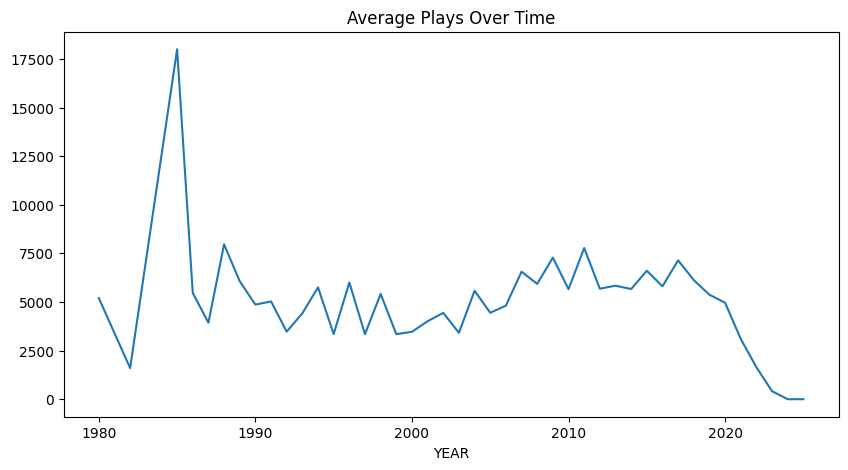

In [26]:
df.groupby("YEAR")["PLAYS"].mean().plot(figsize=(10,5))
plt.title("Average Plays Over Time")
plt.show()

Insight:
Game engagement shows significant variability over time, with a general increase during the 2000s and 2010s. 
However, extreme peaks in earlier years (e.g., 1980s) are likely driven by small sample sizes rather than true industry trends.

In [27]:
df.groupby("DECADE")["PLAYS"].mean().sort_values()

DECADE
2020    2566.804255
1990    4364.386792
2000    5218.392593
2010    6118.790554
1980    6340.000000
Name: PLAYS, dtype: float64

Insight:
Games from the 2010s show the most consistent high engagement. 
Although the 1980s appear to have higher averages, this is likely due to a small number of observations rather than a true trend. 
Recent years (2020s) show lower averages, possibly due to incomplete data for newer releases.

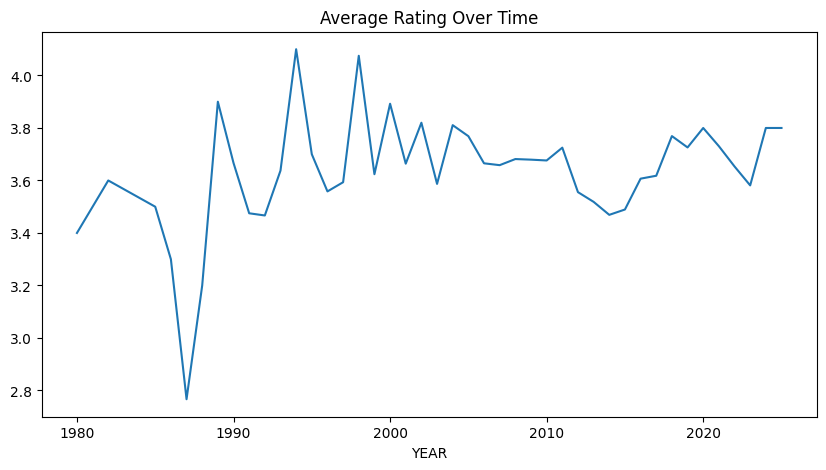

In [28]:
df.groupby("YEAR")["RATING"].mean().plot(figsize=(10,5))
plt.title("Average Rating Over Time")
plt.show()

Insight:
Ratings remain relatively stable over time, generally fluctuating between 3.5 and 4.0. 
This suggests that perceived game quality has remained consistent, despite significant growth in player engagement and industry expansion.

In [29]:
df.groupby("MONTH")["PLAYS"].mean()

MONTH
1     4891.629032
2     4306.847059
3     4832.900990
4     6188.064516
5     5612.050847
6     4689.402778
7     4144.579710
8     3945.217949
9     5210.484848
10    5291.921986
11    6232.475000
12    3423.945652
Name: PLAYS, dtype: float64

Insight:
Engagement appears higher in months such as April and November, which may be associated with major game release cycles and holiday seasons.

## Correlation Analysis

<Axes: >

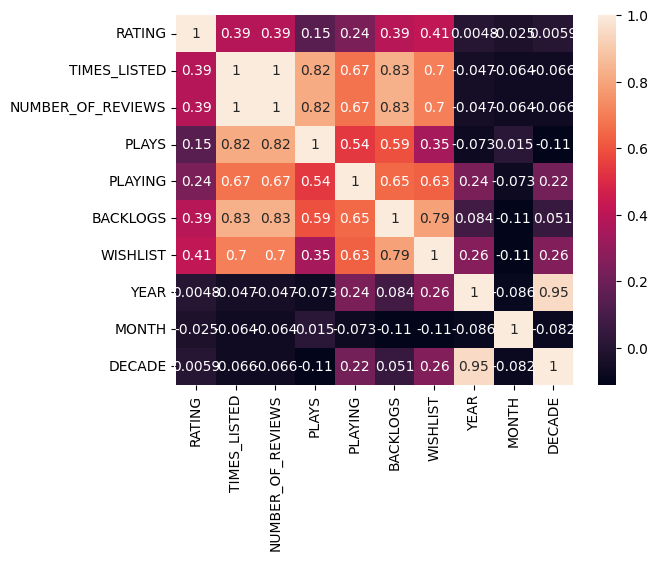

In [30]:
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True)

Insight:
Engagement-related variables such as Times Listed, Number of Reviews, and Plays show strong positive correlations, indicating they capture similar aspects of player activity.

In contrast, Rating shows weak correlations with most variables, suggesting that game quality is not strongly driven by popularity or engagement metrics.

This reinforces the idea that popularity and perceived quality are not the same.

## Conclusion

- Popular games are driven by strong franchises and brand recognition  
- Competitive genres generate higher engagement  
- Niche genres tend to achieve higher ratings  
- Developer reputation plays a key role in quality  
- Engagement has grown significantly in recent decades  

Overall, game success is driven by a combination of genre, engagement, and developer quality, while ratings remain relatively independent from popularity.